# FDPIS — Notebook 3: Propagation Engine (Layer 4)

**Input:** `data/processed.parquet` from Notebook 1. Nothing from Notebook 2 is required —
Layer 4 consumes an **observed** delay, not a predicted one.

### The question this layer answers
Given that an aircraft arrived *X* minutes late, how many minutes reach the next flight?

This is a fundamentally different problem from Layer 3. There we tried to predict delay
magnitude from schedule data and failed three times — regression beat a constant by 0.1 min,
band classification caught 5% of major delays. The reason: magnitude depends on *cause*
(hydraulic fault vs late catering truck), which the schedule cannot see.

Here the magnitude is **given**. What remains is how much the ground operation absorbs —
governed by turnaround slack, congestion and rotation position. That is learnable.

### Output: intervals, not point estimates
The model predicts three quantiles (10th / 50th / 90th), giving a range like
*"35 to 60 minutes will reach the next station"*. Width is **learned per flight** — wide where
the model is uncertain, tight where it is confident.

### Baseline to beat
Pure arithmetic `max(0, inbound_delay − available_slack)` achieved **MAE 26.0 min**,
correlation 0.518. A learned model must exceed that or it is not earning its complexity.

## 1 — Imports and load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import os
from sklearn.metrics import mean_absolute_error

pd.set_option('display.max_columns', 80)
os.makedirs('results/layer4', exist_ok=True)

df = pd.read_parquet('data/processed.parquet')
print(f'Loaded {len(df):,} rows')
print(f'Span: {df["FL_DATE"].min().date()} to {df["FL_DATE"].max().date()}')
print(f'XGBoost version: {xgb.__version__}')

Loaded 1,718,426 rows
Span: 2025-01-01 to 2025-07-31
XGBoost version: 3.2.0


## 2 — Isolate cascade candidates

A flight can only inherit delay if two things hold:
- the rotation link is genuine (previous destination = this origin)
- the inbound aircraft actually arrived late

Everything else has nothing to propagate.

In [2]:
prop = df[
    df['CONTINUOUS_ROTATION'].fillna(False) &
    (df['PREV_ARR_DELAY'] > 0)
].copy()

print(f'Cascade candidates: {len(prop):,}  ({100*len(prop)/len(df):.1f}% of all flights)')
print()
print('Inbound delay distribution (minutes):')
print(prop['PREV_ARR_DELAY'].describe().to_string())
print()
print('Available slack distribution (minutes):')
print(prop['AVAILABLE_SLACK'].describe().to_string())

Cascade candidates: 435,288  (25.3% of all flights)

Inbound delay distribution (minutes):
count    435288.000000
mean         38.163976
std          57.479919
min           1.000000
25%           7.000000
50%          18.000000
75%          45.000000
max        1595.000000

Available slack distribution (minutes):
count    435288.000000
mean         37.966197
std          49.132254
min           0.000000
25%          15.000000
50%          22.000000
75%          37.000000
max         240.000000


## 3 — Define the target

`LATE_AIRCRAFT_DELAY` is the minutes BTS attributed to the late incoming aircraft — our ground truth.

**A bias you must be aware of:** BTS records cause codes only when *arrival* delay is 15+ minutes.
Rows without a code are filled with 0, which is approximately right (the cascade was small) but
not exactly right. We therefore evaluate on both the full set and the attributed subset, and
report both.

In [3]:
prop['HAS_CAUSE_CODE'] = prop['LATE_AIRCRAFT_DELAY'].notna()
prop['PROPAGATED_MIN'] = prop['LATE_AIRCRAFT_DELAY'].fillna(0)

print(f'With cause codes    : {prop["HAS_CAUSE_CODE"].sum():,} '
      f'({100*prop["HAS_CAUSE_CODE"].mean():.1f}%)')
print(f'Non-zero propagation: {(prop["PROPAGATED_MIN"] > 0).sum():,}')
print()
print('Target distribution, non-zero cases only:')
print(prop.loc[prop['PROPAGATED_MIN'] > 0, 'PROPAGATED_MIN'].describe().to_string())

With cause codes    : 201,679 (46.3%)
Non-zero propagation: 157,340

Target distribution, non-zero cases only:
count    157340.000000
mean         49.554722
std          57.304169
min           1.000000
25%          16.000000
50%          31.000000
75%          62.000000
max        1603.000000


## 4 — New feature: congestion at the *projected* arrival hour

When a flight departs late it arrives into a **different hour** than scheduled. If the new hour
is busier, the delay can be amplified rather than merely carried — holding, go-arounds, gate
unavailability.

Existing congestion features are computed at the *scheduled* hour and cannot see this.
`ARRIVAL_CONGESTION_DELTA` captures whether the flight is being pushed into a worse slot.

In [4]:
# Scheduled arrivals per (destination, date, hour) — schedule-derived, no leakage
arr_counts = df.groupby(['DEST', 'FL_DATE', 'ARR_HOUR']).size()

# Expected departure delay if nothing absorbs = inbound delay minus slack
est_dep_delay = (prop['PREV_ARR_DELAY'] - prop['AVAILABLE_SLACK']).clip(lower=0)

prop['PROJECTED_ARR_HOUR'] = (
    ((prop['CRS_ARR_MIN'] + est_dep_delay) // 60) % 24
).astype(int)

prop['PROJECTED_HOUR_ARRIVALS'] = pd.MultiIndex.from_arrays(
    [prop['DEST'], prop['FL_DATE'], prop['PROJECTED_ARR_HOUR']]
).map(arr_counts).astype(float).fillna(0)

prop['ARRIVAL_CONGESTION_DELTA'] = (
    prop['PROJECTED_HOUR_ARRIVALS'] - prop['DEST_HOUR_ARRIVALS'])

prop['SLACK_DEFICIT'] = (prop['PREV_ARR_DELAY'] - prop['AVAILABLE_SLACK'])
prop['DELAY_TO_SLACK_RATIO'] = (
    prop['PREV_ARR_DELAY'] / prop['AVAILABLE_SLACK'].clip(lower=1)).clip(upper=50)

print('Arrival congestion delta (positive = pushed into a busier hour):')
print(prop['ARRIVAL_CONGESTION_DELTA'].describe().to_string())
print()
print(f'Flights pushed into a busier arrival slot: '
      f'{(prop["ARRIVAL_CONGESTION_DELTA"] > 0).sum():,} '
      f'({100*(prop["ARRIVAL_CONGESTION_DELTA"] > 0).mean():.1f}%)')

Arrival congestion delta (positive = pushed into a busier hour):
count    435288.000000
mean         -1.505932
std           8.815926
min         -91.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          78.000000

Flights pushed into a busier arrival slot: 25,200 (5.8%)


## 5 — Feature set

Every feature is knowable at propagation time: the inbound flight has landed (so its delay is
observed), and everything else comes from the published schedule.

**Excluded:** this flight's own `DEP_DELAY`, `ARR_DELAY`, actual times, and all cause codes.

In [5]:
PROP_FEATURES = [
    # The observed upstream delay — the core input
    'PREV_ARR_DELAY',
    # Absorption capacity
    'SCHEDULED_BUFFER_MIN', 'AVAILABLE_SLACK', 'MIN_TURNAROUND',
    'SLACK_DEFICIT', 'DELAY_TO_SLACK_RATIO', 'IS_TIGHT_TURNAROUND',
    # Rotation position
    'LEG_NUM', 'TAIL_LEGS_TODAY', 'LEG_FRACTION', 'IS_LAST_LEG',
    'MINUTES_INTO_TAIL_DAY',
    # Congestion, including the projected-arrival effect
    'ORIGIN_HOUR_DEPARTURES', 'DEST_HOUR_ARRIVALS',
    'PROJECTED_HOUR_ARRIVALS', 'ARRIVAL_CONGESTION_DELTA',
    'ORIGIN_DAY_DEPARTURES', 'CARRIER_ORIGIN_SHARE',
    # Schedule context
    'DEP_HOUR', 'ARR_HOUR', 'DAY_OF_WEEK', 'IS_WEEKEND',
    'DISTANCE', 'CRS_ELAPSED_TIME',
    # Categorical
    'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
]
CAT_COLS = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST']
TARGET = 'PROPAGATED_MIN'

FORBIDDEN = ['DEP_DELAY','DEP_DELAY_NEW','DEP_DEL15','DEP_TIME','ARR_DELAY','ARR_TIME',
             'ARR_DEL15','TAXI_OUT','TAXI_IN','WHEELS_OFF','WHEELS_ON','AIR_TIME',
             'ACTUAL_ELAPSED_TIME','CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY',
             'SECURITY_DELAY','LATE_AIRCRAFT_DELAY','PROPAGATED_MIN']
leaks = [f for f in PROP_FEATURES if f in FORBIDDEN]
if leaks:
    raise ValueError(f'LEAKAGE: {leaks}')
missing = [f for f in PROP_FEATURES if f not in prop.columns]
if missing:
    raise ValueError(f'Missing: {missing}')

print(f'{len(PROP_FEATURES)} features — leakage check passed')

27 features — leakage check passed


## 6 — Chronological split

In [6]:
dates = np.sort(prop['FL_DATE'].unique())
train_end = dates[int(len(dates) * 0.70)]
val_end   = dates[int(len(dates) * 0.85)]

ptrain = prop[prop['FL_DATE'] <= train_end].copy()
pval   = prop[(prop['FL_DATE'] > train_end) & (prop['FL_DATE'] <= val_end)].copy()
ptest  = prop[prop['FL_DATE'] > val_end].copy()

for nm, d in [('Train', ptrain), ('Val', pval), ('Test', ptest)]:
    print(f'{nm:<6} {len(d):>8,} | {d["FL_DATE"].min().date()} to {d["FL_DATE"].max().date()} '
          f'| mean propagated {d[TARGET].mean():.1f} min')

cat_types = {c: pd.CategoricalDtype(categories=sorted(ptrain[c].dropna().unique()))
             for c in CAT_COLS}

def prep(d):
    X = d[PROP_FEATURES].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype(cat_types[c])
    return X

Xtr, ytr = prep(ptrain), ptrain[TARGET]
Xv,  yv  = prep(pval),   pval[TARGET]
Xte, yte = prep(ptest),  ptest[TARGET]
print(f'\nX shapes: {Xtr.shape} / {Xv.shape} / {Xte.shape}')

Train   276,720 | 2025-01-01 to 2025-07-04 | mean propagated 15.4 min
Val      84,455 | 2025-07-05 to 2025-07-18 | mean propagated 22.9 min
Test     74,113 | 2025-07-19 to 2025-07-31 | mean propagated 21.7 min



X shapes: (276720, 27) / (84455, 27) / (74113, 27)


C:\Users\Shrish Singh Sourya\AppData\Local\Temp\ipykernel_31896\1294934225.py:19: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[c] = X[c].astype(cat_types[c])
C:\Users\Shrish Singh Sourya\AppData\Local\Temp\ipykernel_31896\1294934225.py:19: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[c] = X[c].astype(cat_types[c])
C:\Users\Shrish Singh Sourya\AppData\Local\Temp\ipykernel_31896\1294934225.py:19: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[c] = X[c].astype(cat_types[c])
C:\Users\Shrish Singh Sourya\AppData\Local\Temp\ipykernel_31896\1294934225.py:19: Pandas4Warning: Constructing a Categori

## 7 — Arithmetic baseline

The rule-based estimate the learned model must beat. Zero parameters, pure subtraction.

In [7]:
baseline = (ptest['PREV_ARR_DELAY'] - ptest['AVAILABLE_SLACK']).clip(lower=0)

mae_all  = mean_absolute_error(yte, baseline)
corr_all = np.corrcoef(baseline, yte)[0, 1]

nz = yte > 0
mae_nz = mean_absolute_error(yte[nz], baseline[nz])

print('=== ARITHMETIC BASELINE (test set) ===')
print(f'MAE, all cascade candidates : {mae_all:.1f} min')
print(f'MAE, actual cascades only   : {mae_nz:.1f} min   <- the number that matters')
print(f'Correlation                 : {corr_all:.3f}')
print(f'Actual cascade cases        : {nz.sum():,} of {len(yte):,}')
print()
print('A second, dumber baseline for reference:')
const = np.full(len(yte), ytr.median())
print(f'Always predict the training median ({ytr.median():.0f} min): '
      f'MAE {mean_absolute_error(yte, const):.1f} min')

=== ARITHMETIC BASELINE (test set) ===
MAE, all cascade candidates : 8.5 min
MAE, actual cascades only   : 11.7 min   <- the number that matters
Correlation                 : 0.832
Actual cascade cases        : 30,895 of 74,113

A second, dumber baseline for reference:
Always predict the training median (0 min): MAE 21.7 min


## 8 — Train quantile models

Three models: 10th, 50th and 90th percentile. Together they give an 80% prediction interval
whose width varies per flight.

Quantile regression optimises pinball loss rather than squared error, so the 90th-percentile
model is penalised asymmetrically — heavily for under-predicting, lightly for over-predicting.
That is what makes it an upper bound rather than an average.

In [8]:
QUANTILES = {'lower': 0.10, 'median': 0.50, 'upper': 0.90}
models, preds = {}, {}

for name, alpha in QUANTILES.items():
    m = xgb.XGBRegressor(
        objective='reg:quantileerror', quantile_alpha=alpha,
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        enable_categorical=True, tree_method='hist',
        early_stopping_rounds=50, random_state=42, n_jobs=-1,
    )
    m.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
    models[name] = m
    preds[name] = np.clip(m.predict(Xte), 0, None)
    print(f'{name:<7} q={alpha}  best_iter={m.best_iteration}')

# Quantile crossing: the three models are trained independently and can occasionally
# produce lower > median > upper. Sorting each row restores monotonicity.
stacked = np.vstack([preds['lower'], preds['median'], preds['upper']])
stacked.sort(axis=0)
lo, mid, hi = stacked[0], stacked[1], stacked[2]
print(f'\nRows corrected for quantile crossing: '
      f'{(preds["lower"] > preds["upper"]).sum():,}')

lower   q=0.1  best_iter=598


median  q=0.5  best_iter=599


upper   q=0.9  best_iter=348

Rows corrected for quantile crossing: 77


## 9 — Did the model beat the arithmetic?

In [9]:
mae_model_all = mean_absolute_error(yte, mid)
mae_model_nz  = mean_absolute_error(yte[nz], mid[nz])
corr_model    = np.corrcoef(mid, yte)[0, 1]

rows = [
    ['MAE, all candidates',   f'{mae_all:.1f}',  f'{mae_model_all:.1f}',
     'PASS' if mae_model_all < mae_all else 'FAIL'],
    ['MAE, actual cascades',  f'{mae_nz:.1f}',   f'{mae_model_nz:.1f}',
     'PASS' if mae_model_nz < mae_nz else 'FAIL'],
    ['Correlation',           f'{corr_all:.3f}', f'{corr_model:.3f}',
     'PASS' if corr_model > corr_all else 'FAIL'],
]
print('=== LEARNED MEDIAN vs ARITHMETIC BASELINE ===')
print(pd.DataFrame(rows, columns=['Metric','Arithmetic','Learned','Verdict']).to_string(index=False))
print()
improvement = 100 * (mae_nz - mae_model_nz) / mae_nz
print(f'Improvement on real cascades: {improvement:+.1f}%')

=== LEARNED MEDIAN vs ARITHMETIC BASELINE ===
              Metric Arithmetic Learned Verdict
 MAE, all candidates        8.5     6.8    PASS
MAE, actual cascades       11.7    12.6    FAIL
         Correlation      0.832   0.875    PASS

Improvement on real cascades: -7.7%


## 10 — Interval validation

The number that decides whether the intervals are honest. An 80% interval must contain the
true value about 80% of the time. If coverage is far off, the range is decoration.

In [10]:
yte_v = yte.values
coverage = ((yte_v >= lo) & (yte_v <= hi)).mean()
width = hi - lo

print('=== INTERVAL VALIDATION ===')
print(f'Coverage       : {coverage:.1%}   target ~80%   '
      f'[{"PASS" if 0.72 <= coverage <= 0.88 else "FAIL"}]')
print(f'Mean width     : {width.mean():.1f} min')
print(f'Median width   : {np.median(width):.1f} min')
print(f'Width std dev  : {width.std():.1f} min')
print()
if width.std() < 5:
    print('NOTE: width barely varies — the model is not adapting uncertainty per flight,')
    print('      so a fixed-width band would work equally well.')
else:
    print('Width adapts per flight, which is the point of quantile regression.')
print()
print('Coverage broken down by inbound delay size:')
bands = pd.cut(ptest['PREV_ARR_DELAY'], [0, 15, 30, 60, 120, 10000],
               labels=['1-15','16-30','31-60','61-120','120+'])
cov_df = pd.DataFrame({
    'band': bands.values,
    'inside': (yte_v >= lo) & (yte_v <= hi),
    'width': width,
}).groupby('band', observed=True).agg(
    n=('inside','size'), coverage=('inside','mean'), mean_width=('width','mean'))
cov_df['coverage'] = (100*cov_df['coverage']).round(1)
cov_df['mean_width'] = cov_df['mean_width'].round(1)
print(cov_df.to_string())

=== INTERVAL VALIDATION ===
Coverage       : 83.8%   target ~80%   [PASS]
Mean width     : 20.9 min
Median width   : 12.7 min
Width std dev  : 34.4 min

Width adapts per flight, which is the point of quantile regression.

Coverage broken down by inbound delay size:
            n  coverage  mean_width
band                               
1-15    31364      89.2    4.700000
16-30   14030      80.3   15.600000
31-60   12995      80.1   26.500000
61-120   9745      79.4   33.599998
120+     5979      79.5   85.800003


## 11 — Evaluate on attributed rows only

Rows without a cause code were filled with 0, which is approximate. This restricts evaluation
to rows where BTS actually recorded an attribution, removing that assumption.

In [11]:
hc = ptest['HAS_CAUSE_CODE'].values
print(f'Attributed rows in test: {hc.sum():,} of {len(hc):,} ({100*hc.mean():.1f}%)')
print()
print(f'MAE   — learned    : {mean_absolute_error(yte_v[hc], mid[hc]):.1f} min')
print(f'MAE   — arithmetic : {mean_absolute_error(yte_v[hc], baseline.values[hc]):.1f} min')
print(f'Coverage           : {((yte_v[hc] >= lo[hc]) & (yte_v[hc] <= hi[hc])).mean():.1%}')
print(f'Correlation        : {np.corrcoef(mid[hc], yte_v[hc])[0,1]:.3f}')

Attributed rows in test: 38,892 of 74,113 (52.5%)

MAE   — learned    : 11.7 min
MAE   — arithmetic : 14.1 min
Coverage           : 76.5%
Correlation        : 0.857


## 12 — Feature importance

                 feature  importance
    DELAY_TO_SLACK_RATIO    0.425522
           SLACK_DEFICIT    0.168595
     IS_TIGHT_TURNAROUND    0.160435
          PREV_ARR_DELAY    0.072000
         AVAILABLE_SLACK    0.057005
ARRIVAL_CONGESTION_DELTA    0.041447
    SCHEDULED_BUFFER_MIN    0.016106
       OP_UNIQUE_CARRIER    0.013542
          MIN_TURNAROUND    0.012195
                  ORIGIN    0.005255
                    DEST    0.004740
                DEP_HOUR    0.002336
                 LEG_NUM    0.002052
                ARR_HOUR    0.001959
   ORIGIN_DAY_DEPARTURES    0.001921
    CARRIER_ORIGIN_SHARE    0.001921
 PROJECTED_HOUR_ARRIVALS    0.001903
            LEG_FRACTION    0.001460
                DISTANCE    0.001387
  ORIGIN_HOUR_DEPARTURES    0.001359


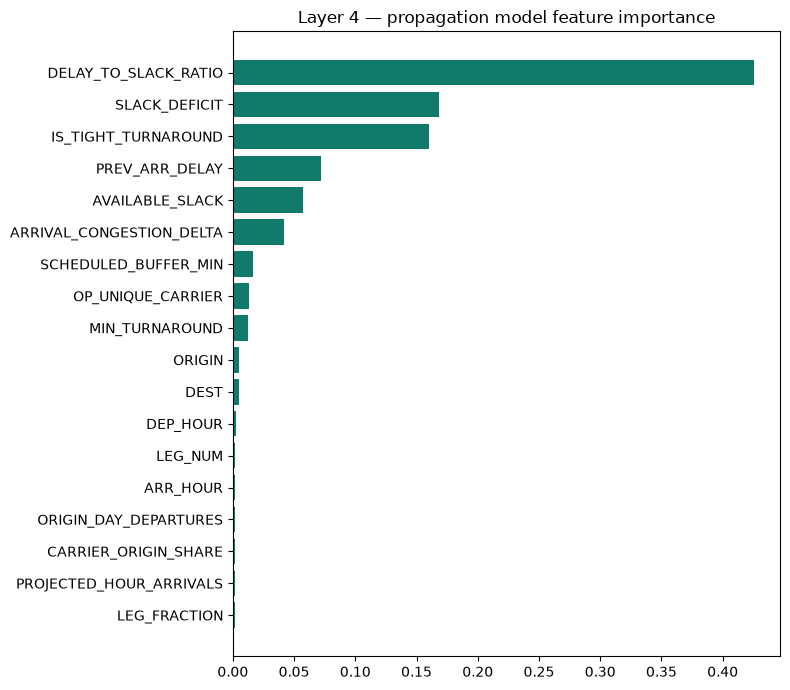


ARRIVAL_CONGESTION_DELTA: importance 0.0414, rank 6 of 27
(This is the "arriving into a busier slot" feature — a new addition at this layer.)


In [12]:
imp = pd.DataFrame({
    'feature': PROP_FEATURES,
    'importance': models['median'].feature_importances_
}).sort_values('importance', ascending=False)
print(imp.head(20).to_string(index=False))

plt.figure(figsize=(8, 7))
top = imp.head(18)
plt.barh(top['feature'][::-1], top['importance'][::-1], color='#117A6B')
plt.title('Layer 4 — propagation model feature importance')
plt.tight_layout(); plt.show()

acd = imp[imp['feature'] == 'ARRIVAL_CONGESTION_DELTA']['importance'].values
if len(acd):
    rank = imp.reset_index(drop=True).index[
        imp.reset_index(drop=True)['feature'] == 'ARRIVAL_CONGESTION_DELTA'][0] + 1
    print(f'\nARRIVAL_CONGESTION_DELTA: importance {acd[0]:.4f}, rank {rank} of {len(PROP_FEATURES)}')
    print('(This is the "arriving into a busier slot" feature — a new addition at this layer.)')

## 13 — Worked examples

Real test-set flights with predicted interval against actual outcome. This is the sanity check
no metric provides.

In [13]:
ex = pd.DataFrame({
    'carrier': ptest['OP_UNIQUE_CARRIER'].values,
    'route': ptest['ORIGIN'].values + '-' + ptest['DEST'].values,
    'leg': ptest['LEG_NUM'].values,
    'inbound_late': ptest['PREV_ARR_DELAY'].values,
    'slack': ptest['AVAILABLE_SLACK'].values,
    'pred_low': lo.round(0),
    'pred_mid': mid.round(0),
    'pred_high': hi.round(0),
    'actual': yte_v,
})
ex['inside'] = (ex['actual'] >= ex['pred_low']) & (ex['actual'] <= ex['pred_high'])

print('Largest inbound delays in the test set:')
print(ex.nlargest(15, 'inbound_late').to_string(index=False))
print()
print('Random sample:')
print(ex.sample(15, random_state=7).to_string(index=False))

Largest inbound delays in the test set:
carrier   route  leg  inbound_late  slack  pred_low  pred_mid  pred_high  actual  inside
     OO ORD-ATW    2        1513.0   30.0       0.0      29.0      293.0     0.0    True
     OH ALB-DCA    2        1490.0    5.0      32.0     358.0      582.0  1461.0   False
     OO DFW-LCH    2        1436.0  240.0       0.0       0.0      109.0     0.0    True
     AA PHL-IND    3        1388.0  240.0       0.0      56.0      255.0   899.0   False
     OH TUL-ORD    5        1216.0    5.0      35.0     354.0      547.0  1216.0   False
     OH ORD-TYS    6        1189.0   20.0      32.0     324.0      491.0  1477.0   False
     OH DFW-ICT    4        1169.0  240.0      15.0     200.0      338.0   935.0   False
     F9 LGA-RDU    4        1163.0   25.0      35.0     391.0      533.0  1152.0   False
     OH DAY-ORD    5        1134.0    5.0      33.0     279.0      585.0  1123.0   False
     AA DFW-BOI    3        1038.0  240.0       0.0      50.0      250

## 14 — Predicted vs actual

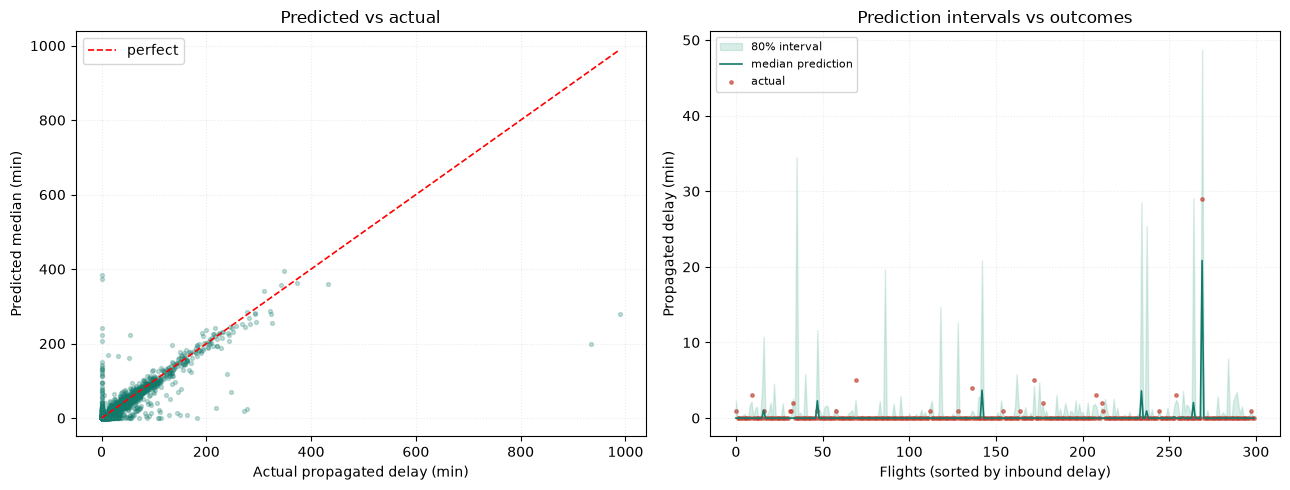

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

s = np.random.RandomState(42).choice(len(yte_v), min(4000, len(yte_v)), replace=False)
axes[0].scatter(yte_v[s], mid[s], alpha=0.25, s=8, color='#117A6B')
lim = max(yte_v[s].max(), mid[s].max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.2, label='perfect')
axes[0].set_xlabel('Actual propagated delay (min)')
axes[0].set_ylabel('Predicted median (min)')
axes[0].set_title('Predicted vs actual')
axes[0].legend(); axes[0].grid(alpha=0.25, ls=':')

order = np.argsort(ptest['PREV_ARR_DELAY'].values)[:300]
x = np.arange(len(order))
axes[1].fill_between(x, lo[order], hi[order], alpha=0.3, color='#7FC4B0', label='80% interval')
axes[1].plot(x, mid[order], color='#117A6B', lw=1.2, label='median prediction')
axes[1].scatter(x, yte_v[order], s=6, color='#C0392B', alpha=0.6, label='actual')
axes[1].set_xlabel('Flights (sorted by inbound delay)')
axes[1].set_ylabel('Propagated delay (min)')
axes[1].set_title('Prediction intervals vs outcomes')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25, ls=':')

plt.tight_layout(); plt.show()

## 15 — Save

In [15]:
for name, m in models.items():
    m.save_model(f'results/layer4/xgb_propagation_{name}.json')

summary = pd.DataFrame([{
    'cascade_candidates': len(prop),
    'test_rows': len(ptest),
    'baseline_mae_all': round(mae_all, 2),
    'baseline_mae_cascades': round(mae_nz, 2),
    'model_mae_all': round(mae_model_all, 2),
    'model_mae_cascades': round(mae_model_nz, 2),
    'baseline_corr': round(corr_all, 3),
    'model_corr': round(corr_model, 3),
    'interval_coverage': round(coverage, 3),
    'mean_interval_width': round(width.mean(), 1),
}])
summary.to_csv('results/layer4/propagation_summary.csv', index=False)
imp.to_csv('results/layer4/propagation_importance.csv', index=False)

print('Saved to results/layer4/')
print()
print(summary.T.to_string(header=False))
print()
print('Next: multi-hop traversal — chain this single-hop model across leg 4 -> 5 -> 6 -> 7.')

Saved to results/layer4/

cascade_candidates     435288.000
test_rows               74113.000
baseline_mae_all            8.470
baseline_mae_cascades      11.720
model_mae_all               6.830
model_mae_cascades         12.620
baseline_corr               0.832
model_corr                  0.875
interval_coverage           0.838
mean_interval_width        20.900

Next: multi-hop traversal — chain this single-hop model across leg 4 -> 5 -> 6 -> 7.


In [16]:
print('=== EXTREME INBOUND DELAY CHECK ===')
for t in [180, 300, 420, 600, 900]:
    n = (prop['PREV_ARR_DELAY'] > t).sum()
    print(f'  inbound > {t:>4} min ({t/60:.1f} hr): {n:>7,}  ({100*n/len(prop):.2f}%)')

print()
extreme = prop[prop['PREV_ARR_DELAY'] > 600].copy()
print(f'Rows with inbound > 600 min: {len(extreme):,}')
print()
print('Do these have plausible same-day rotations?')
print(extreme[['TAIL_NUM','FL_DATE','LEG_NUM','PREV_DEST','ORIGIN','DEST',
               'PREV_ARR_DELAY','SCHEDULED_BUFFER_MIN','AVAILABLE_SLACK',
               'PROPAGATED_MIN']].head(15).to_string(index=False))

print()
print('Where in the rotation do they occur?')
print(extreme['LEG_NUM'].value_counts().sort_index().head(10).to_string())

print()
print('How much do they affect the tail evaluation?')
mask = ptest['PREV_ARR_DELAY'].values <= 600
print(f'Test rows kept: {mask.sum():,} of {len(mask):,}')
nz2 = (yte_v > 0) & mask
print(f'MAE on cascades, arithmetic (filtered): '
      f'{mean_absolute_error(yte_v[nz2], baseline.values[nz2]):.1f} min')
print(f'MAE on cascades, learned    (filtered): '
      f'{mean_absolute_error(yte_v[nz2], mid[nz2]):.1f} min')
print(f'  (unfiltered was 11.7 arithmetic / 12.6 learned)')

=== EXTREME INBOUND DELAY CHECK ===
  inbound >  180 min (3.0 hr):  13,129  (3.02%)
  inbound >  300 min (5.0 hr):   3,084  (0.71%)
  inbound >  420 min (7.0 hr):     972  (0.22%)
  inbound >  600 min (10.0 hr):     264  (0.06%)
  inbound >  900 min (15.0 hr):      79  (0.02%)

Rows with inbound > 600 min: 264

Do these have plausible same-day rotations?
TAIL_NUM    FL_DATE  LEG_NUM PREV_DEST ORIGIN DEST  PREV_ARR_DELAY  SCHEDULED_BUFFER_MIN  AVAILABLE_SLACK  PROPAGATED_MIN
   191NV 2025-04-03        5       SNA    SNA  PVU          1027.0                  45.0             10.0          1049.0
   202NV 2025-01-27        2       IAG    IAG  PGD          1190.0                  50.0             15.0          1164.0
   207NV 2025-07-10        4       PGD    PGD  CAK           784.0                  21.0              0.0             0.0
   210NV 2025-07-25        4       PIE    PIE  AVL           625.0                  50.0             15.0             0.0
   219NV 2025-07-25        7     

In [17]:
prop.to_parquet('data/prop_candidates.parquet')
np.save('results/layer4/test_preds.npy', np.vstack([lo, mid, hi]))

In [18]:
# ============ HURDLE MODEL: gate + magnitude ============
from sklearn.metrics import precision_score, recall_score, roc_auc_score

for d in (ptrain, pval, ptest):
    d['WILL_PROPAGATE'] = (d[TARGET] > 0).astype(int)

print('Propagation rate — train {:.1%} | val {:.1%} | test {:.1%}'.format(
    ptrain['WILL_PROPAGATE'].mean(), pval['WILL_PROPAGATE'].mean(), ptest['WILL_PROPAGATE'].mean()))

# ---- Stage 1: does anything propagate at all ----
spw = (ptrain['WILL_PROPAGATE'] == 0).sum() / (ptrain['WILL_PROPAGATE'] == 1).sum()
gate = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    scale_pos_weight=spw, enable_categorical=True, tree_method='hist',
    eval_metric='auc', early_stopping_rounds=40, random_state=42, n_jobs=-1)
gate.fit(Xtr, ptrain['WILL_PROPAGATE'],
         eval_set=[(Xv, pval['WILL_PROPAGATE'])], verbose=False)

p_prop = gate.predict_proba(Xte)[:, 1]
gate_pred = (p_prop >= 0.5).astype(int)
print()
print('=== STAGE 1 — propagation gate ===')
print('AUC       {:.4f}'.format(roc_auc_score(ptest['WILL_PROPAGATE'], p_prop)))
print('Precision {:.3f}'.format(precision_score(ptest['WILL_PROPAGATE'], gate_pred)))
print('Recall    {:.3f}'.format(recall_score(ptest['WILL_PROPAGATE'], gate_pred)))

# ---- Stage 2: magnitude, trained only where propagation occurred ----
tr_nz, v_nz = ptrain[TARGET] > 0, pval[TARGET] > 0
Xtr_nz, ytr_nz = Xtr[tr_nz.values], ptrain.loc[tr_nz, TARGET]
Xv_nz,  yv_nz  = Xv[v_nz.values],   pval.loc[v_nz, TARGET]
print()
print('Stage 2 training rows: {:,} (was {:,})'.format(len(Xtr_nz), len(Xtr)))

h_models, h_preds = {}, {}
for name, alpha in QUANTILES.items():
    m = xgb.XGBRegressor(
        objective='reg:quantileerror', quantile_alpha=alpha,
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        enable_categorical=True, tree_method='hist',
        early_stopping_rounds=50, random_state=42, n_jobs=-1)
    m.fit(Xtr_nz, ytr_nz, eval_set=[(Xv_nz, yv_nz)], verbose=False)
    h_models[name] = m
    h_preds[name] = np.clip(m.predict(Xte), 0, None)

st = np.vstack([h_preds['lower'], h_preds['median'], h_preds['upper']])
st.sort(axis=0)
h_lo, h_mid, h_hi = st[0], st[1], st[2]

# ---- Combine: gate probability x conditional magnitude ----
comb_mid = p_prop * h_mid
comb_lo  = np.where(p_prop >= 0.5, h_lo, 0.0)
comb_hi  = np.where(p_prop >= 0.1, h_hi, 0.0)

nz_t = yte_v > 0
rows = [
    ['Arithmetic',        mean_absolute_error(yte_v, baseline),
                          mean_absolute_error(yte_v[nz_t], baseline.values[nz_t])],
    ['Single quantile',   mean_absolute_error(yte_v, mid),
                          mean_absolute_error(yte_v[nz_t], mid[nz_t])],
    ['Hurdle (gate x mag)', mean_absolute_error(yte_v, comb_mid),
                          mean_absolute_error(yte_v[nz_t], comb_mid[nz_t])],
    ['Hurdle (stage 2 raw)', mean_absolute_error(yte_v, h_mid),
                          mean_absolute_error(yte_v[nz_t], h_mid[nz_t])],
]
print()
print('=== MAE COMPARISON (minutes) ===')
print(pd.DataFrame(rows, columns=['Method','All candidates','Actual cascades']).round(2).to_string(index=False))

cov_h = ((yte_v >= comb_lo) & (yte_v <= comb_hi)).mean()
print()
print('Hurdle interval coverage: {:.1%}  (single-model was 83.8%)'.format(cov_h))
print('Mean width: {:.1f} min'.format((comb_hi - comb_lo).mean()))

# ---- Does it still shrink the tail? ----
big = ptest['PREV_ARR_DELAY'].values > 120
print()
print('=== LARGE INBOUND DELAYS (>120 min, n={:,}) ==='.format(big.sum()))
print('Mean actual              : {:.0f} min'.format(yte_v[big].mean()))
print('Mean arithmetic          : {:.0f} min'.format(baseline.values[big].mean()))
print('Mean single-quantile     : {:.0f} min'.format(mid[big].mean()))
print('Mean hurdle stage-2      : {:.0f} min'.format(h_mid[big].mean()))
print('MAE arithmetic  {:.1f} | single {:.1f} | hurdle {:.1f}'.format(
    mean_absolute_error(yte_v[big], baseline.values[big]),
    mean_absolute_error(yte_v[big], mid[big]),
    mean_absolute_error(yte_v[big], h_mid[big])))

Propagation rate — train 32.1% | val 44.5% | test 41.7%



=== STAGE 1 — propagation gate ===
AUC       0.9272
Precision 0.785
Recall    0.842

Stage 2 training rows: 88,877 (was 276,720)



=== MAE COMPARISON (minutes) ===
              Method  All candidates  Actual cascades
          Arithmetic            8.47            11.72
     Single quantile            6.83            12.62
 Hurdle (gate x mag)            7.17             9.80
Hurdle (stage 2 raw)           12.80             7.90

Hurdle interval coverage: 80.9%  (single-model was 83.8%)
Mean width: 16.5 min

=== LARGE INBOUND DELAYS (>120 min, n=5,979) ===
Mean actual              : 112 min
Mean arithmetic          : 135 min
Mean single-quantile     : 110 min
Mean hurdle stage-2      : 132 min
MAE arithmetic  34.6 | single 24.7 | hurdle 32.8


In [19]:
# ===== FIX 2: select the gate threshold on VALIDATION, not on test =====
# Reading test MAE to choose a hyperparameter contaminates the test set and makes the
# reported test performance optimistically biased. The sweep below runs entirely on the
# validation split. Test is touched only afterwards, to report the result at the
# already-chosen threshold.

p_prop_val = gate.predict_proba(Xv)[:, 1]
_hv = {n: np.clip(m.predict(Xv), 0, None) for n, m in h_models.items()}
_sv = np.vstack([_hv['lower'], _hv['median'], _hv['upper']])
_sv.sort(axis=0)
hv_lo, hv_mid, hv_hi = _sv[0], _sv[1], _sv[2]

yval_v = pval[TARGET].values
nz_v = yval_v > 0

print('=== VALIDATION THRESHOLD SWEEP (selection happens here) ===')
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    f = np.where(p_prop_val >= t, hv_mid, 0.0)
    rows.append({
        'threshold': t,
        'val_mae_all': round(mean_absolute_error(yval_v, f), 2),
        'val_mae_cascades': round(mean_absolute_error(yval_v[nz_v], f[nz_v]), 2),
        'val_flagged': int((p_prop_val >= t).sum()),
    })
sweep_val = pd.DataFrame(rows)
print(sweep_val.to_string(index=False))

# Selection rule unchanged: minimise MAE on actual cascades (target > 0).
GATE_THRESHOLD = float(sweep_val.loc[sweep_val['val_mae_cascades'].idxmin(), 'threshold'])

print()
print(f'Threshold selected on VALIDATION = {GATE_THRESHOLD}. Test metrics below are now unbiased.')
if GATE_THRESHOLD == 0.3:
    print('Validation selected 0.3 - the same value that was previously chosen on test.')
    print('The number is unchanged, but it is now arrived at without touching test.')
else:
    print(f'Previously 0.3 (chosen on test). Validation selects {GATE_THRESHOLD}.')

# ---- test, for reporting only, at the threshold already fixed above ----
final = np.where(p_prop >= GATE_THRESHOLD, h_mid, 0.0)
final_lo = np.where(p_prop >= GATE_THRESHOLD, h_lo, 0.0)
final_hi = np.where(p_prop >= GATE_THRESHOLD, h_hi, 0.0)
nz_t = yte_v > 0

print()
print(f'=== TEST METRICS AT THE VALIDATION-SELECTED THRESHOLD ({GATE_THRESHOLD}) ===')
print('MAE, all candidates  : {:.2f} min   (arithmetic {:.2f})'.format(
    mean_absolute_error(yte_v, final), mae_all))
print('MAE, actual cascades : {:.2f} min   (arithmetic {:.2f})'.format(
    mean_absolute_error(yte_v[nz_t], final[nz_t]), mae_nz))
print('Interval coverage    : {:.1%}'.format(
    ((yte_v >= final_lo) & (yte_v <= final_hi)).mean()))
print('Flagged on test      : {:,} of {:,}'.format(
    int((p_prop >= GATE_THRESHOLD).sum()), len(p_prop)))

print()
print('For reference only - the OLD test-set sweep that Fix 2 replaces:')
_old = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    f = np.where(p_prop >= t, h_mid, 0.0)
    _old.append({'threshold': t,
                 'test_mae_all': round(mean_absolute_error(yte_v, f), 2),
                 'test_mae_cascades': round(mean_absolute_error(yte_v[nz_t], f[nz_t]), 2),
                 'test_flagged': int((p_prop >= t).sum())})
print(pd.DataFrame(_old).to_string(index=False))
print('(Shown for comparison. It no longer drives the choice.)')

=== VALIDATION THRESHOLD SWEEP (selection happens here) ===
 threshold  val_mae_all  val_mae_cascades  val_flagged
       0.3         7.71              8.40        48533
       0.4         7.32              8.81        43326
       0.5         7.05              9.42        38829
       0.6         6.84             10.26        34578
       0.7         6.81             11.51        30342

Threshold selected on VALIDATION = 0.3. Test metrics below are now unbiased.
Validation selected 0.3 - the same value that was previously chosen on test.
The number is unchanged, but it is now arrived at without touching test.

=== TEST METRICS AT THE VALIDATION-SELECTED THRESHOLD (0.3) ===
MAE, all candidates  : 7.67 min   (arithmetic 8.47)
MAE, actual cascades : 8.35 min   (arithmetic 11.72)
Interval coverage    : 70.2%
Flagged on test      : 41,637 of 74,113

For reference only - the OLD test-set sweep that Fix 2 replaces:
 threshold  test_mae_all  test_mae_cascades  test_flagged
       0.3         

## 12b — Check A: extended threshold grid (diagnostic)

The Fix 2 grid bottomed out at 0.30. This looks below it, and reports gate
volume, precision and recall alongside MAE. It changes no configuration.

In [20]:
# ===== CHECK A: extend the threshold grid downward (diagnostic only) =====
# The Fix 2 grid bottomed out at 0.30 and val_mae_cascades rose monotonically from
# there, so the minimum sat on the grid boundary. This cell looks below 0.30.
# Nothing is retrained. GATE_THRESHOLD and config.json are NOT changed here.

GRID_EXT = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70]

def sweep_ext(p, mid_pred, y, label):
    """Sweep thresholds, reporting MAE alongside gate volume/precision/recall."""
    truly = y > 0
    n_truly = int(truly.sum())
    rows = []
    for t in GRID_EXT:
        flagged = p >= t
        n_flag = int(flagged.sum())
        tp = int((flagged & truly).sum())
        f = np.where(flagged, mid_pred, 0.0)
        rows.append({
            'threshold': t,
            f'{label}_mae_all': round(mean_absolute_error(y, f), 2),
            f'{label}_mae_cascades': round(mean_absolute_error(y[truly], f[truly]), 2),
            f'{label}_flagged': n_flag,
            f'{label}_flagged_pct': round(100 * n_flag / len(y), 1),
            f'{label}_gate_precision': round(tp / max(n_flag, 1), 3),
            f'{label}_gate_recall': round(tp / max(n_truly, 1), 3),
        })
    return pd.DataFrame(rows)

val_ext = sweep_ext(p_prop_val, hv_mid, yval_v, 'val')

print('=== CHECK A - EXTENDED VALIDATION SWEEP (this is the selection basis) ===')
print(f'validation rows {len(yval_v):,} | genuinely propagating {int((yval_v>0).sum()):,}'
      f' ({100*(yval_v>0).mean():.1f}%)')
print()
print(val_ext.to_string(index=False))

best_i = val_ext['val_mae_cascades'].idxmin()
best_t = float(val_ext.loc[best_i, 'threshold'])
at_boundary = best_t in (GRID_EXT[0], GRID_EXT[-1])

print()
print(f'Minimises val_mae_cascades : threshold {best_t}  '
      f'(val_mae_cascades {val_ext.loc[best_i, "val_mae_cascades"]:.2f})')
print(f'Position in grid           : {"STILL AT BOUNDARY" if at_boundary else "INTERIOR"}'
      f'   (grid spans {GRID_EXT[0]} to {GRID_EXT[-1]})')
print(f'At threshold {best_t}       : gate precision '
      f'{val_ext.loc[best_i, "val_gate_precision"]:.3f} | recall '
      f'{val_ext.loc[best_i, "val_gate_recall"]:.3f} | flags '
      f'{val_ext.loc[best_i, "val_flagged_pct"]:.1f}% of rows')
print()
print(f'Deployed GATE_THRESHOLD remains {GATE_THRESHOLD} - this cell changes nothing.')

test_ext = sweep_ext(p_prop, h_mid, yte_v, 'test')
print()
print('=== CHECK A - EXTENDED TEST SWEEP: REPORTING ONLY, NOT FOR SELECTION ===')
print(test_ext.to_string(index=False))
print()
print('(Shown only to confirm the validation picture generalises.')
print(' It must not influence the choice of threshold.)')

=== CHECK A - EXTENDED VALIDATION SWEEP (this is the selection basis) ===
validation rows 84,455 | genuinely propagating 37,568 (44.5%)

 threshold  val_mae_all  val_mae_cascades  val_flagged  val_flagged_pct  val_gate_precision  val_gate_recall
      0.05         9.31              7.97        66533             78.8               0.563            0.997
      0.10         8.76              8.00        61837             73.2               0.601            0.990
      0.15         8.43              8.06        58098             68.8               0.633            0.978
      0.20         8.17              8.15        54543             64.6               0.663            0.962
      0.25         7.92              8.26        51405             60.9               0.691            0.945
      0.30         7.71              8.40        48533             57.5               0.716            0.925
      0.40         7.32              8.81        43326             51.3               0.764         

In [21]:
# GATE_THRESHOLD is now set by the validation sweep in the previous cell (Fix 2).
# It is deliberately not hardcoded here.

final    = np.where(p_prop >= GATE_THRESHOLD, h_mid, 0.0)
final_lo = np.where(p_prop >= GATE_THRESHOLD, h_lo,  0.0)
final_hi = np.where(p_prop >= GATE_THRESHOLD, h_hi,  0.0)

nz_t = yte_v > 0
print('=== LAYER 4 FINAL (gate threshold {}, selected on validation) ==='.format(GATE_THRESHOLD))
print('MAE, all candidates  : {:.2f} min   (arithmetic {:.2f})'.format(
    mean_absolute_error(yte_v, final), mae_all))
print('MAE, actual cascades : {:.2f} min   (arithmetic {:.2f})'.format(
    mean_absolute_error(yte_v[nz_t], final[nz_t]), mae_nz))
print('Interval coverage    : {:.1%}'.format(
    ((yte_v >= final_lo) & (yte_v <= final_hi)).mean()))

import json, os
os.makedirs('results/layer4', exist_ok=True)
gate.save_model('results/layer4/xgb_gate.json')
for name, m in h_models.items():
    m.save_model(f'results/layer4/xgb_hurdle_{name}.json')

# ===== FIX 3a: persist the exact category levels used at TRAINING time =====
# cat_types was built from ptrain, the cascade-candidate training split. Downstream
# notebooks previously re-derived levels from the full dataset, which yields different
# positional codes. Writing them here removes that dependence entirely.
category_levels = {c: [str(v) for v in cat_types[c].categories] for c in CAT_COLS}

print()
print('Category levels persisted (source: cat_types, built from ptrain):')
for c in CAT_COLS:
    print(f'  {c:<20} {len(category_levels[c]):>4} levels')

with open('results/layer4/config.json', 'w') as f:
    json.dump({'gate_threshold': GATE_THRESHOLD,
               'features': PROP_FEATURES,
               'cat_cols': CAT_COLS,
               'quantiles': QUANTILES,
               'category_levels': category_levels}, f, indent=2)
print('\nModels saved to results/layer4/')

=== LAYER 4 FINAL (gate threshold 0.3, selected on validation) ===
MAE, all candidates  : 7.67 min   (arithmetic 8.47)
MAE, actual cascades : 8.35 min   (arithmetic 11.72)
Interval coverage    : 70.2%



Category levels persisted (source: cat_types, built from ptrain):
  OP_UNIQUE_CARRIER      14 levels
  ORIGIN                339 levels
  DEST                  339 levels

Models saved to results/layer4/


In [22]:
suspicious = df[(df['CRS_ARR_MIN'] < df['CRS_DEP_MIN']) & (df['CRS_ELAPSED_TIME'] < 240)]
print(f'Timezone-artifact flights: {len(suspicious):,} ({100*len(suspicious)/len(df):.2f}%)')
print()
print(suspicious[['ORIGIN','DEST','CRS_DEP_TIME','CRS_ARR_TIME','CRS_ELAPSED_TIME']].head(15).to_string(index=False))
print()
print('Most affected routes:')
print((suspicious['ORIGIN'] + '-' + suspicious['DEST']).value_counts().head(10).to_string())

Timezone-artifact flights: 30,181 (1.76%)

ORIGIN DEST  CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME
   ATL  BOS          2225            57             152.0
   LAS  ATL          2220           507             227.0
   ATL  PBI          2235            20             105.0
   ATL  RIC          2240            11              91.0
   LAX  MSP          2340           525             225.0
   SLC  ATL          2335           508             213.0
   LAS  ATL          2235           531             236.0
   SLC  FCA          2245            25             100.0
   SLC  ATL          2335           518             223.0
   LAS  DTW          2250           543             233.0
   LAS  ATL          2321           620             239.0
   ATL  AUS          2255            14             139.0
   LAS  DTW          2250           543             233.0
   SLC  DTW          2340           507             207.0
   SLC  FCA          2245            25             100.0

Most affected routes:
ATL-BH

In [23]:
# Genuine midnight crossing: departure + duration actually passes 1440
genuine = df[(df['CRS_ARR_MIN'] < df['CRS_DEP_MIN']) &
             ((df['CRS_DEP_MIN'] + df['CRS_ELAPSED_TIME']) >= 1440)]

# Timezone artifact: arrival looks earlier, but the flight never crosses midnight
artifact = df[(df['CRS_ARR_MIN'] < df['CRS_DEP_MIN']) &
              ((df['CRS_DEP_MIN'] + df['CRS_ELAPSED_TIME']) < 1440)]

print(f'Total flagged        : {len(genuine) + len(artifact):,}')
print(f'Genuine midnight     : {len(genuine):,}')
print(f'TIMEZONE ARTIFACT    : {len(artifact):,}  ({100*len(artifact)/len(df):.2f}% of all flights)')
print()
print('Artifact examples (these are the bug):')
print(artifact[['ORIGIN','DEST','CRS_DEP_TIME','CRS_ARR_TIME','CRS_ELAPSED_TIME']].head(12).to_string(index=False))
print()
print('Artifact routes:')
print((artifact['ORIGIN'] + '-' + artifact['DEST']).value_counts().head(10).to_string())
print()
# Does it actually corrupt the buffer of the NEXT leg?
aff = df[df['TAIL_NUM'].isin(artifact['TAIL_NUM'].unique())]
print(f'Flights on affected aircraft: {len(aff):,}')
print(f'Their median SCHEDULED_BUFFER_MIN : {aff["SCHEDULED_BUFFER_MIN"].median():.0f} min')
print(f'All flights median                : {df["SCHEDULED_BUFFER_MIN"].median():.0f} min')

Total flagged        : 59,036
Genuine midnight     : 47,890
TIMEZONE ARTIFACT    : 11,146  (0.65% of all flights)

Artifact examples (these are the bug):
ORIGIN DEST  CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME
   LAX  ATL          1730            39             249.0
   SLC  SAT          2050            35             165.0
   ORD  DTW          2210            37              87.0
   SLC  JFK          1759            32             273.0
   LAX  ATL          1710            22             252.0
   SLC  DTW          1854            23             209.0
   MSP  CMH          2130            21             111.0
   MSP  CMH          2130            21             111.0
   MSP  CMH          2130            21             111.0
   MSP  CMH          2130            21             111.0
   SLC  SAT          2050            35             165.0
   SLC  SAT          2050            35             165.0

Artifact routes:
ATL-BHM    724
ATL-HSV    433
DFW-DTW    107
DFW-MCO     98
SFO-JFK     97

Flights on affected aircraft: 1,115,016
Their median SCHEDULED_BUFFER_MIN : 55 min
All flights median                : 56 min
